In [1]:
import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_auc_score, classification_report
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import optuna
import matplotlib.pyplot as plt
import seaborn as sns

# Load and prepare data
df = pd.read_csv(r'C:\Users\shriv\Documents\churn_prediction\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Cleaning
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

# Encoding
df['Churn'] = (df['Churn'] == 'Yes').astype(int)
df['gender'] = (df['gender'] == 'Male').astype(int)
df['Partner'] = (df['Partner'] == 'Yes').astype(int)
df['Dependents'] = (df['Dependents'] == 'Yes').astype(int)
df['PhoneService'] = (df['PhoneService'] == 'Yes').astype(int)
df['PaperlessBilling'] = (df['PaperlessBilling'] == 'Yes').astype(int)
df = pd.get_dummies(df, columns=[
    'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod'
], drop_first=True)
df.drop(columns=['customerID'], inplace=True)

# Split
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# SMOTE
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Data ready!")
print(f"Training rows: {X_train_res.shape[0]}")
print(f"Testing rows:  {X_test.shape[0]}")

Data ready!
Training rows: 8260
Testing rows:  1407


XGBoost AUC:   0.8174
LightGBM AUC:  0.8174


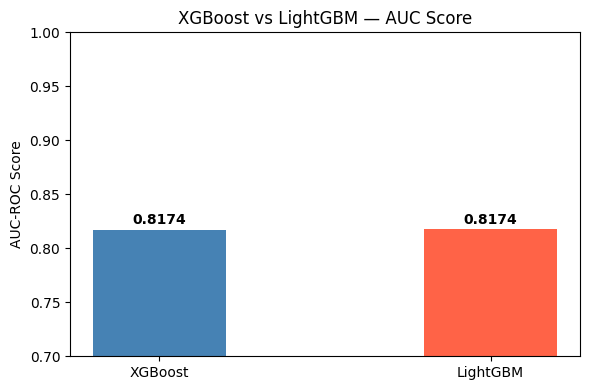


Winner: LightGBM 🏆


In [2]:
# Compare XGBoost vs LightGBM with default settings
results = {}

# Model 1 - XGBoost
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train_res, y_train_res)
xgb_prob = xgb.predict_proba(X_test)[:, 1]
xgb_auc = roc_auc_score(y_test, xgb_prob)
results['XGBoost'] = xgb_auc
print(f"XGBoost AUC:   {xgb_auc:.4f}")

# Model 2 - LightGBM
lgbm = LGBMClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    verbose=-1
)
lgbm.fit(X_train_res, y_train_res)
lgbm_prob = lgbm.predict_proba(X_test)[:, 1]
lgbm_auc = roc_auc_score(y_test, lgbm_prob)
results['LightGBM'] = lgbm_auc
print(f"LightGBM AUC:  {lgbm_auc:.4f}")

# Plot comparison
plt.figure(figsize=(6, 4))
colors = ['steelblue', 'tomato']
plt.bar(results.keys(), results.values(), color=colors, width=0.4)
plt.ylim(0.7, 1.0)
plt.title('XGBoost vs LightGBM — AUC Score')
plt.ylabel('AUC-ROC Score')
for i, (k, v) in enumerate(results.items()):
    plt.text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nWinner: {'XGBoost' if xgb_auc > lgbm_auc else 'LightGBM'} 🏆")

In [3]:
# Use Optuna to automatically find best settings
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'random_state': 42,
        'verbose': -1
    }
    
    model = LGBMClassifier(**params)
    model.fit(X_train_res, y_train_res)
    prob = model.predict_proba(X_test)[:, 1]
    return roc_auc_score(y_test, prob)

# Run 50 trials to find best settings
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print(f"Best AUC found:   {study.best_value:.4f}")
print(f"Previous AUC was: {lgbm_auc:.4f}")
print(f"Improvement:      +{(study.best_value - lgbm_auc):.4f}")
print(f"\nBest settings:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")
    

Best AUC found:   0.8290
Previous AUC was: 0.8174
Improvement:      +0.0116

Best settings:
  n_estimators: 132
  max_depth: 7
  learning_rate: 0.01208899936788132
  subsample: 0.7269660735993628
  colsample_bytree: 0.6285140269996576
  min_child_samples: 14


In [4]:
# Train final model with best settings found by Optuna
best_params = study.best_params
best_params['random_state'] = 42
best_params['verbose'] = -1

final_model = LGBMClassifier(**best_params)
final_model.fit(X_train_res, y_train_res)

# Final evaluation
y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]
final_auc = roc_auc_score(y_test, y_prob)

print("=== Final Model Report ===")
print(f"AUC-ROC Score: {final_auc:.4f}")
print(f"\n{classification_report(y_test, y_pred, target_names=['Stay', 'Churn'])}")


=== Final Model Report ===
AUC-ROC Score: 0.8290

              precision    recall  f1-score   support

        Stay       0.88      0.79      0.83      1033
       Churn       0.55      0.70      0.61       374

    accuracy                           0.77      1407
   macro avg       0.71      0.74      0.72      1407
weighted avg       0.79      0.77      0.77      1407



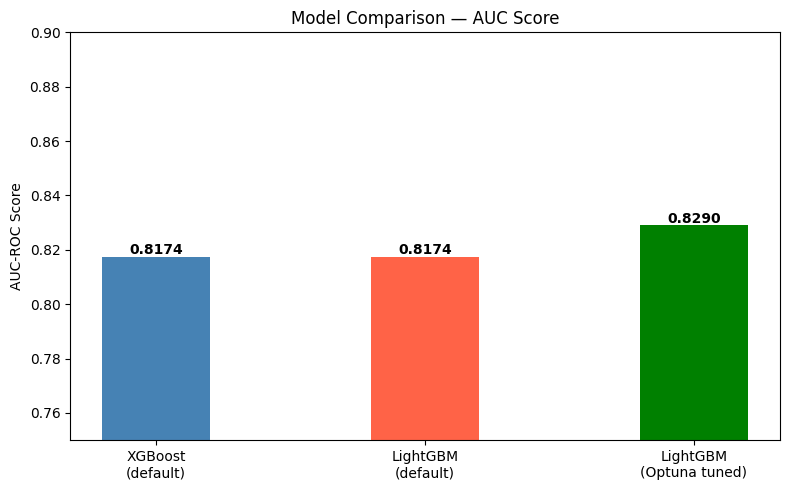


Best model: LightGBM (Optuna tuned) with AUC 0.8290 🏆


In [5]:
# Compare all 3 models together
all_results = {
    'XGBoost\n(default)': xgb_auc,
    'LightGBM\n(default)': lgbm_auc,
    'LightGBM\n(Optuna tuned)': final_auc
}

plt.figure(figsize=(8, 5))
colors = ['steelblue', 'tomato', 'green']
bars = plt.bar(all_results.keys(), all_results.values(), 
               color=colors, width=0.4)
plt.ylim(0.75, 0.90)
plt.title('Model Comparison — AUC Score')
plt.ylabel('AUC-ROC Score')
for i, (k, v) in enumerate(all_results.items()):
    plt.text(i, v + 0.001, f'{v:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nBest model: LightGBM (Optuna tuned) with AUC {final_auc:.4f} 🏆")

In [7]:
import os

# Make sure models folder exists
os.makedirs(r'C:\Users\shriv\Documents\churn_prediction\models', exist_ok=True)

# Save the improved model
with open(r'C:\Users\shriv\Documents\churn_prediction\models\lgbm_churn_tuned.pkl', 'wb') as f:
    pickle.dump(final_model, f)

# Also overwrite the main model so the dashboard uses it
with open(r'C:\Users\shriv\Documents\churn_prediction\models\xgb_churn.pkl', 'wb') as f:
    pickle.dump(final_model, f)

print("✅ Improved model saved!")
print("✅ Dashboard will now use the better model automatically!")

✅ Improved model saved!
✅ Dashboard will now use the better model automatically!
